# Multi-Agent Systems with LangGraph

In [4]:
import sys
import os

# Use current working directory and go one level up
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

# Now you can import your config
from config import api_key

## Chapter 1 - Building agents the LangGraph way!

# Building your agent's toolbox

As you've seen, ***agents*** use ***tools*** to trigger certain actions. That could be executing some code, retrieving a local file, running a web search, or performing a math calculation.

As you progress through this course, you'll build a multi-agent system that can compile financial information, including summaries, stock performance data, and accompanying visualizations of Fortune 500 companies.

Let's start with a single-agent implementation to refresh ourselves on the LangGraph syntax and to create the tools we'll need for the multi-agent case.

In total, there are three tools required:

1. A tool for retrieving company information from the internet &rarr; Wikipedia
2. A tool for retrieving stock performance information from a local CSV file
3. A tool for running Python code to generate the visualizations

Let's start building these tools for your agents to use, beginning with a Wikipedia search tool!

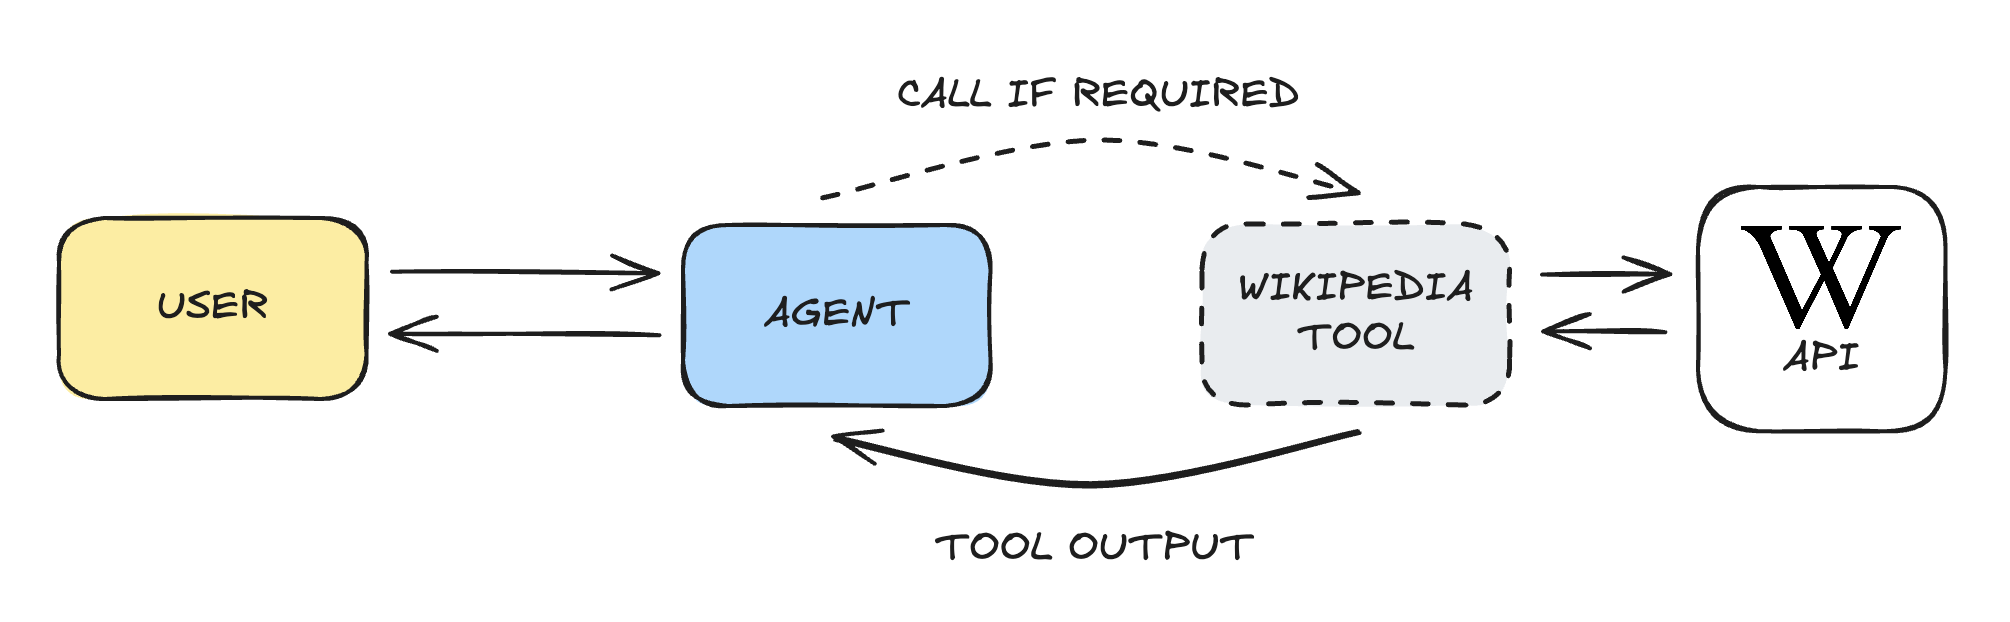

In [5]:
from typing import Annotated
import wikipedia
from langchain_core.tools import tool

@tool
def wikipedia_tool(
    query: Annotated[str, "The Wikipedia search to execute to find key summary information."],
):
    """Use this to search Wikipedia for factual information."""
    try:
        # Step 1: Search using query
        results = wikipedia.search(query)
        
        if not results:
            return "No results found on Wikipedia."
        
        # Step 2: Retrieve page title
        title = results[0]

        # Step 3: Fetch summary
        summary = wikipedia.summary(title, sentences=8, auto_suggest=False, redirect=True)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    return f"Successfully executed:\nWikipedia summary: {summary}"

Tools, like many other LangChain entities, can be called using the `.invoke()` method, passing it the input (if there's only one) or a dictionary mapping the inputs if there are multiple.

In [6]:
company_name = "Apple Inc."
wiki_summary = wikipedia_tool.invoke(f"{company_name}")
print(wiki_summary)

Successfully executed:
Wikipedia summary: Apple Inc. is an American multinational corporation and technology company headquartered in Cupertino, California, in Silicon Valley. It is best known for its consumer electronics, software, and services. Founded in 1976 as Apple Computer Company by Steve Jobs, Steve Wozniak and Ronald Wayne, the company was incorporated by Jobs and Wozniak as Apple Computer, Inc. the following year. It was renamed Apple Inc. in 2007 as the company had expanded its focus from computers to consumer electronics. Apple is the largest technology company by revenue, with US$391.04 billion in the 2024 fiscal year.


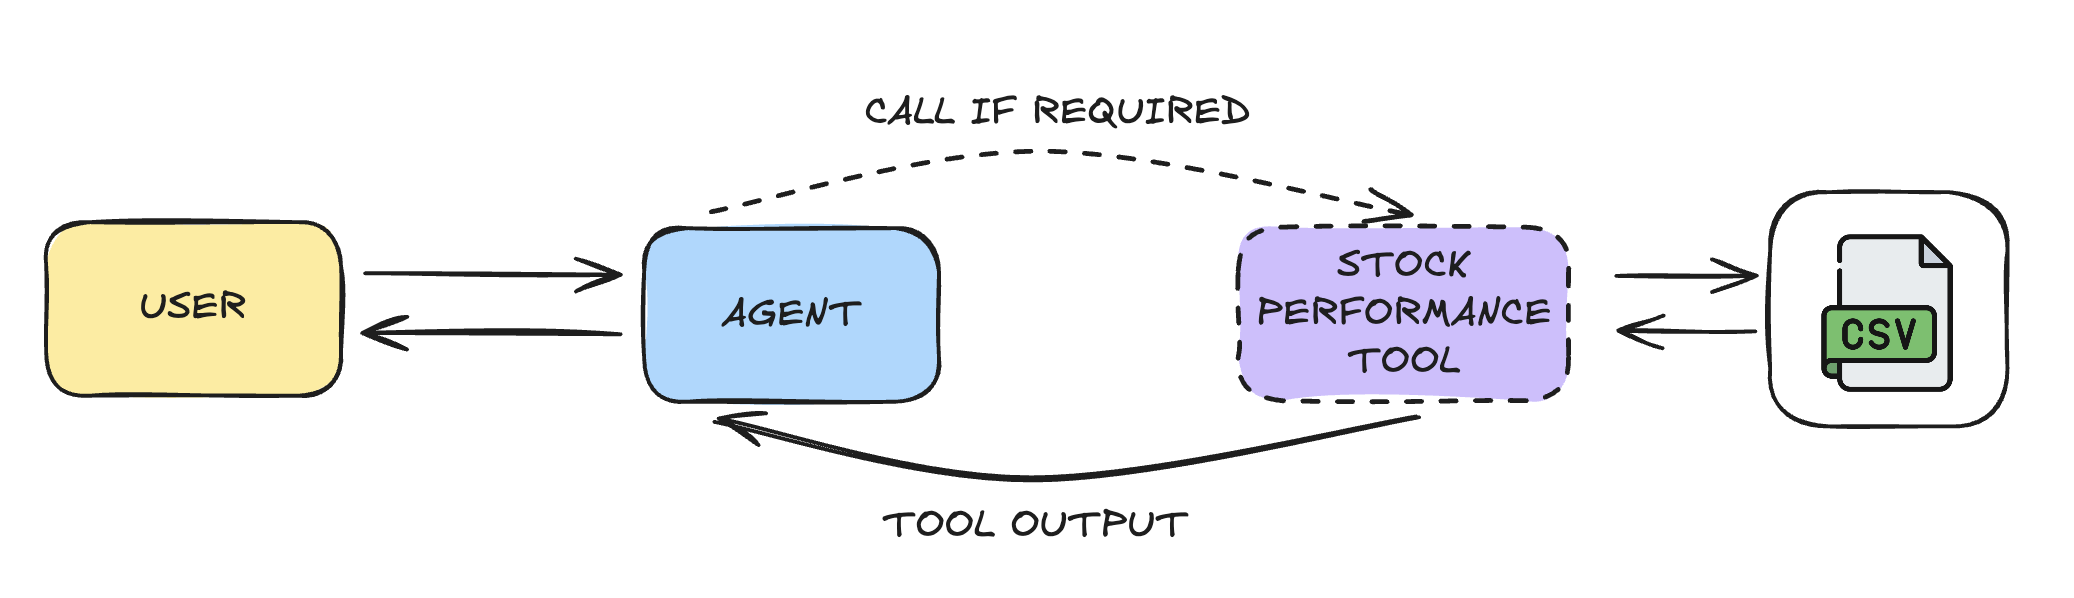

### 📈 Tool 2: Stock performance data

You'll create a tool to load stock performance data from a local CSV file, filter it depending on the user's query, then return the results.

This tool will use stock _ticker symbols_, which are unique company IDs, to return the relevant information for that company. Here are the companies and symbols that have stock data available in your environment:

| Company Name | Ticker Symbol |
|--------------|---------------|
| Apple        | AAPL          |
| Microsoft    | MSFT          |
| Amazon       | AMZN          |
| Meta         | META          |
| Netflix      | NFLX          |
| Tesla        | TSLA          |

Note that this data isn't up-to-date, but you could adapt this to pull real-time data from an API like Yahoo Finance, rather than the CSVs. Try this out after completing the course!

**Complete the code below to define a tool called `stock_data_tool()` that retrieves the last number of days (`num_days`) of stock performance data from local CSV files of a given company, identified by their stock ticker symbol (`company_ticker`)**

In [7]:
import os
from typing import Annotated
import pandas as pd
from langchain_core.tools import tool

@tool
def stock_data_tool(
    company_ticker: Annotated[str, "The ticker symbol of the company to retrieve their stock performance data."], 
    num_days: Annotated[int, "The number of days of stock data required to respond to the user query."]
) -> str:
    """
    Use this to look-up stock performance data for companies to retrieve a table from a CSV. You may need to convert company names into ticker symbols to call this function, e.g, Apple Inc. -> AAPL, and you may need to convert weeks, months, and years, into days.
    """
    
    # Load the CSV for the company requested
    file_path = f"data/{company_ticker}.csv"
    print(file_path)

    if os.path.exists(file_path) is False:
        return f"Sorry, but data for company {company_ticker} is not available. Please try Apple, Amazon, Meta, Microsoft, Netflix, or Tesla."
    
    stock_df = pd.read_csv(file_path, index_col='Date', parse_dates=True)

    # Ensure the index is in date format
    stock_df.index = stock_df.index.date
    
    # Maximum num_days supported by the dataset
    max_num_days = (stock_df.index.max() - stock_df.index.min()).days
    
    if num_days > max_num_days:
        return "Sorry, but this time period exceeds the data available. Please reduce it to continue."
    
    # Get the most recent date in the DataFrame
    final_date = stock_df.index.max()

    # Filter the DataFrame to get the last num_days of stock data
    filtered_df = stock_df[stock_df.index > (final_date - pd.Timedelta(days=num_days))]

    return f"Successfully executed the stock performance data retrieval tool to retrieve the last *{num_days} days* of data for company **{company_ticker}**:\n\n{filtered_df.to_markdown()}"

Because there's two inputs to this tool, we'll need to pass a dictionary of inputs to `.invoke()` instead of a string.

**Invoke your `wikipedia_tool()` on the `company_name` variable.**

In [8]:
retrieved_data = stock_data_tool.invoke({"company_ticker": "META", "num_days": 10})
print(retrieved_data)

data/META.csv
Successfully executed the stock performance data retrieval tool to retrieve the last *10 days* of data for company **META**:

|            | Close/Last   |   Volume | Open    | High      | Low       |
|:-----------|:-------------|---------:|:--------|:----------|:----------|
| 2025-05-28 | $643.58      |  9042874 | $642.60 | $650.88   | $642.5472 |
| 2025-05-27 | $642.32      |  9508367 | $635.41 | $643.08   | $632.75   |
| 2025-05-23 | $627.06      |  8454067 | $624.00 | $632.445  | $622.65   |
| 2025-05-22 | $636.57      |  8228443 | $634.05 | $643.25   | $630.71   |
| 2025-05-21 | $635.50      | 11464570 | $631.79 | $646.61   | $630.17   |
| 2025-05-20 | $637.10      |  6743473 | $636.01 | $639.3536 | $632.26   |
| 2025-05-19 | $640.43      |  9592374 | $628.25 | $643.00   | $627.80   |


Because the table is in Markdown format, we can render it using the `display()` and `Markdown()` functions from `IPython.display`. This makes it possible to automate generating nicely formatted reports!

In [9]:
from IPython.display import display, Markdown
display(Markdown(retrieved_data))

Successfully executed the stock performance data retrieval tool to retrieve the last *10 days* of data for company **META**:

|            | Close/Last   |   Volume | Open    | High      | Low       |
|:-----------|:-------------|---------:|:--------|:----------|:----------|
| 2025-05-28 | $643.58      |  9042874 | $642.60 | $650.88   | $642.5472 |
| 2025-05-27 | $642.32      |  9508367 | $635.41 | $643.08   | $632.75   |
| 2025-05-23 | $627.06      |  8454067 | $624.00 | $632.445  | $622.65   |
| 2025-05-22 | $636.57      |  8228443 | $634.05 | $643.25   | $630.71   |
| 2025-05-21 | $635.50      | 11464570 | $631.79 | $646.61   | $630.17   |
| 2025-05-20 | $637.10      |  6743473 | $636.01 | $639.3536 | $632.26   |
| 2025-05-19 | $640.43      |  9592374 | $628.25 | $643.00   | $627.80   |

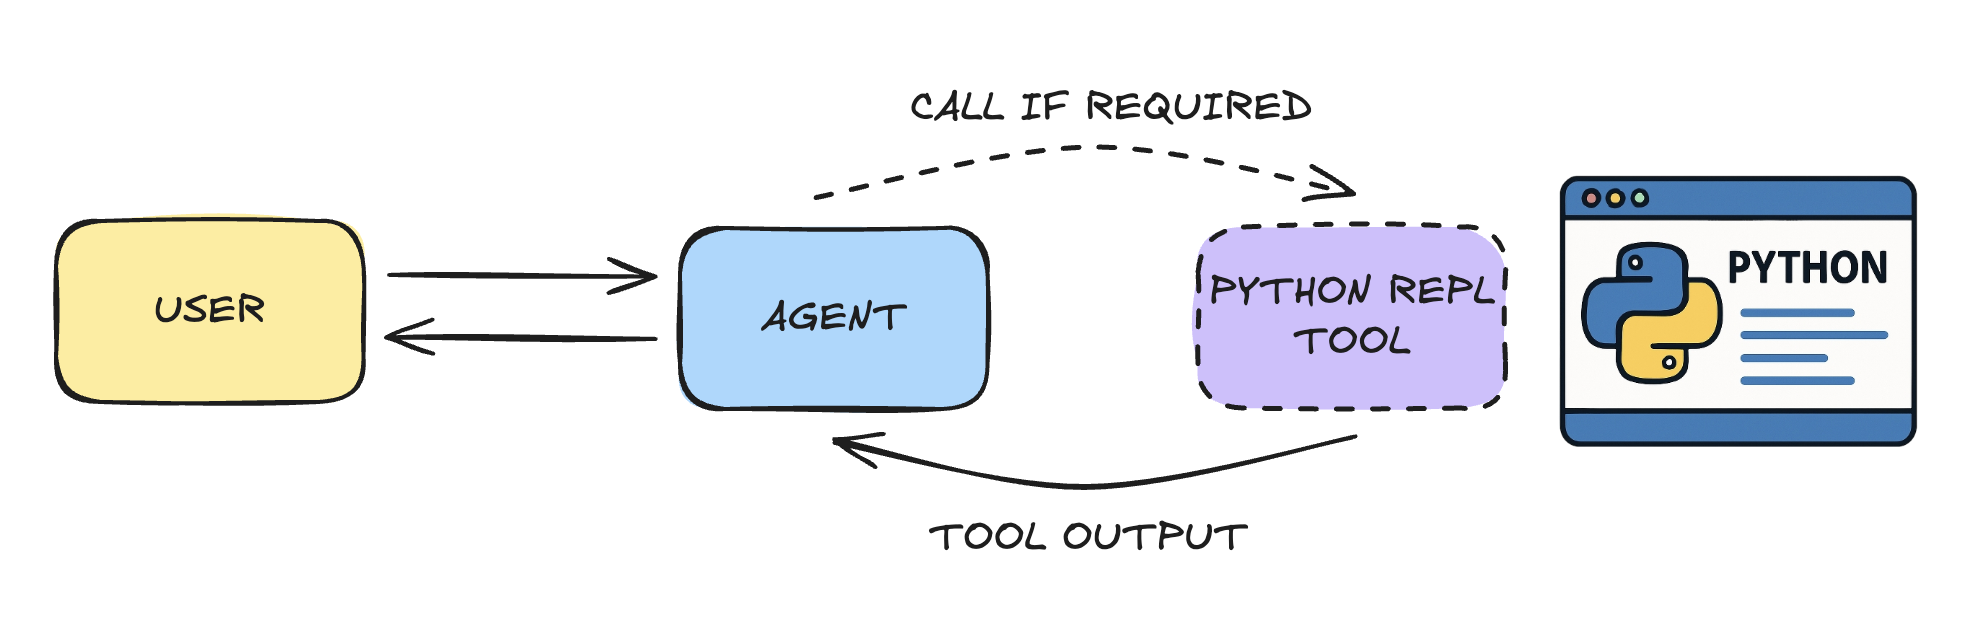

### 💻 Tool 3: Generating and running Python code

The third and final tool you'll need is something to run code to output visualizations based on the stock data retrieved by the Stock performance tool.

This tool uses the `PythonREPL` class, which is available out-of-the-box through LangChain's experimental library, `langchain_experimental`. This class reads Python code written in a string, executes it, and returns the results.

In our agents, the LLM will determine that this tool is required for visualization, generate the code to create the visualization, and call the tool with the code as an input.

**Complete the code below to define a tool called `python_repl_tool()` that can run arbitrary Python code _(`code`).**_

In [10]:
from langchain_core.tools import tool
from typing import Annotated
from langchain_experimental.utilities import PythonREPL

repl = PythonREPL()

@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user. The chart should be displayed using `plt.show()`."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    return f"Successfully executed the Python REPL tool.\n\nPython code executed:\n\`\`\`python\n{code}\n\`\`\`\n\nCode output:\n\`\`\`\n{result}\`\`\`"

**Invoke `python_repl_tool()` on the `code` variable provided and view the code output.**

In [11]:
code = f"""
import numpy as np

arr = np.arange(0, 9)
print(arr)
print(2 * arr)
"""

print(python_repl_tool.invoke({"code": code}))

Python REPL can execute arbitrary code. Use with caution.


Successfully executed the Python REPL tool.

Python code executed:
\`\`\`python

import numpy as np

arr = np.arange(0, 9)
print(arr)
print(2 * arr)

\`\`\`

Code output:
\`\`\`
[0 1 2 3 4 5 6 7 8]
[ 0  2  4  6  8 10 12 14 16]
\`\`\`


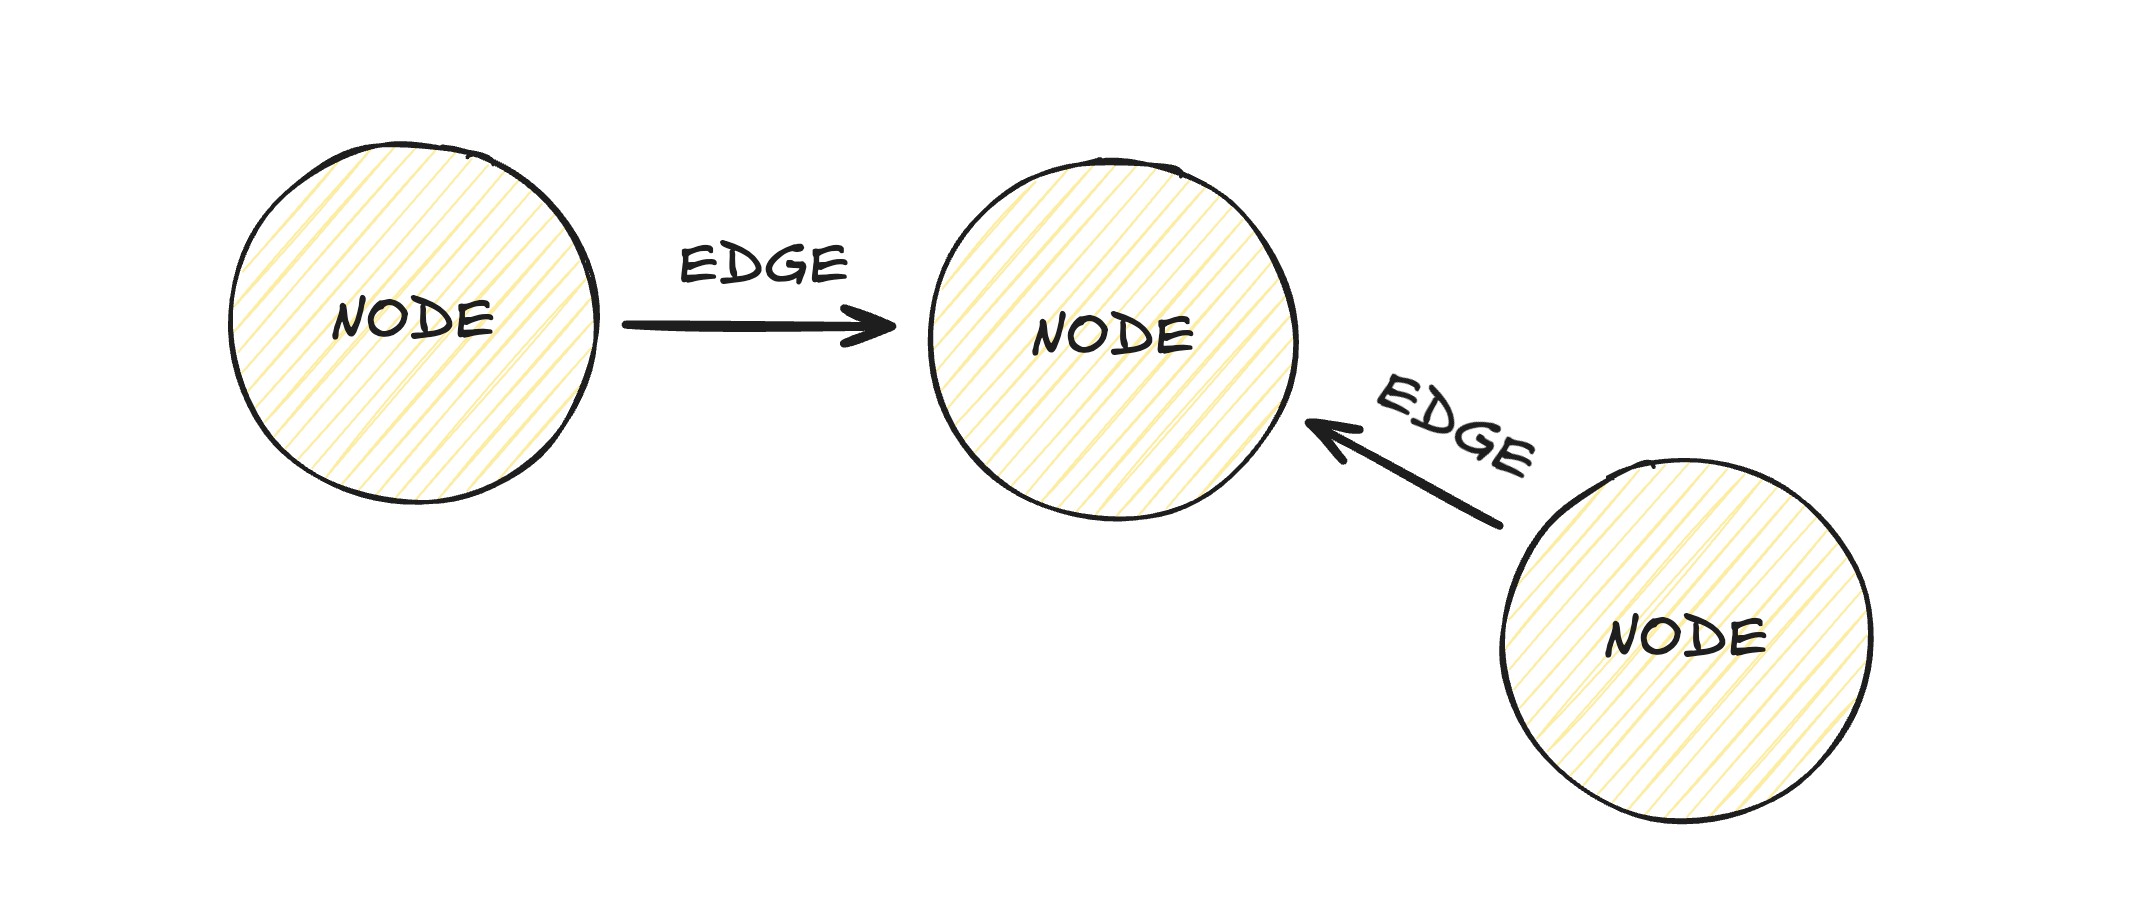

### 🕸️ Agents as graphs (the LangGraph way)

LangGraph was inspired by other graph-based tools to apply a graph-first mode of thinking to agents.

Graph **nodes** and **edges** allow agent developers to map out the exact components and actions to build more complex workflows involving LLMs.

To get started, you'll build a graph state, which will save user and assistant messages in a conversation history, so conversations can progress.

To do this, we first create a `State` class:

```py
class State(TypedDict):
    messages: Annotated[list, add_messages]
```

All this means is that the `State` class has some messages (`messages`), and these messages are a list where new messages are appended to it rather than overridden (indicated with the `add_messages()` function).

This `State` class is then converted into a graph state object using `StateGraph`.

**Complete the code to create a `State` class and convert it into a graph state.**

In [12]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

# Create the state to capture the messages
class State(TypedDict):
    messages: Annotated[list, add_messages]

# Create the graph state
graph_builder = StateGraph(State)

This graph state is often assigned to `graph_builder` or `workflow`, as this object represents the instructions to create the graph rather than the graph itself. This is analogous to a recipe and the final meal.

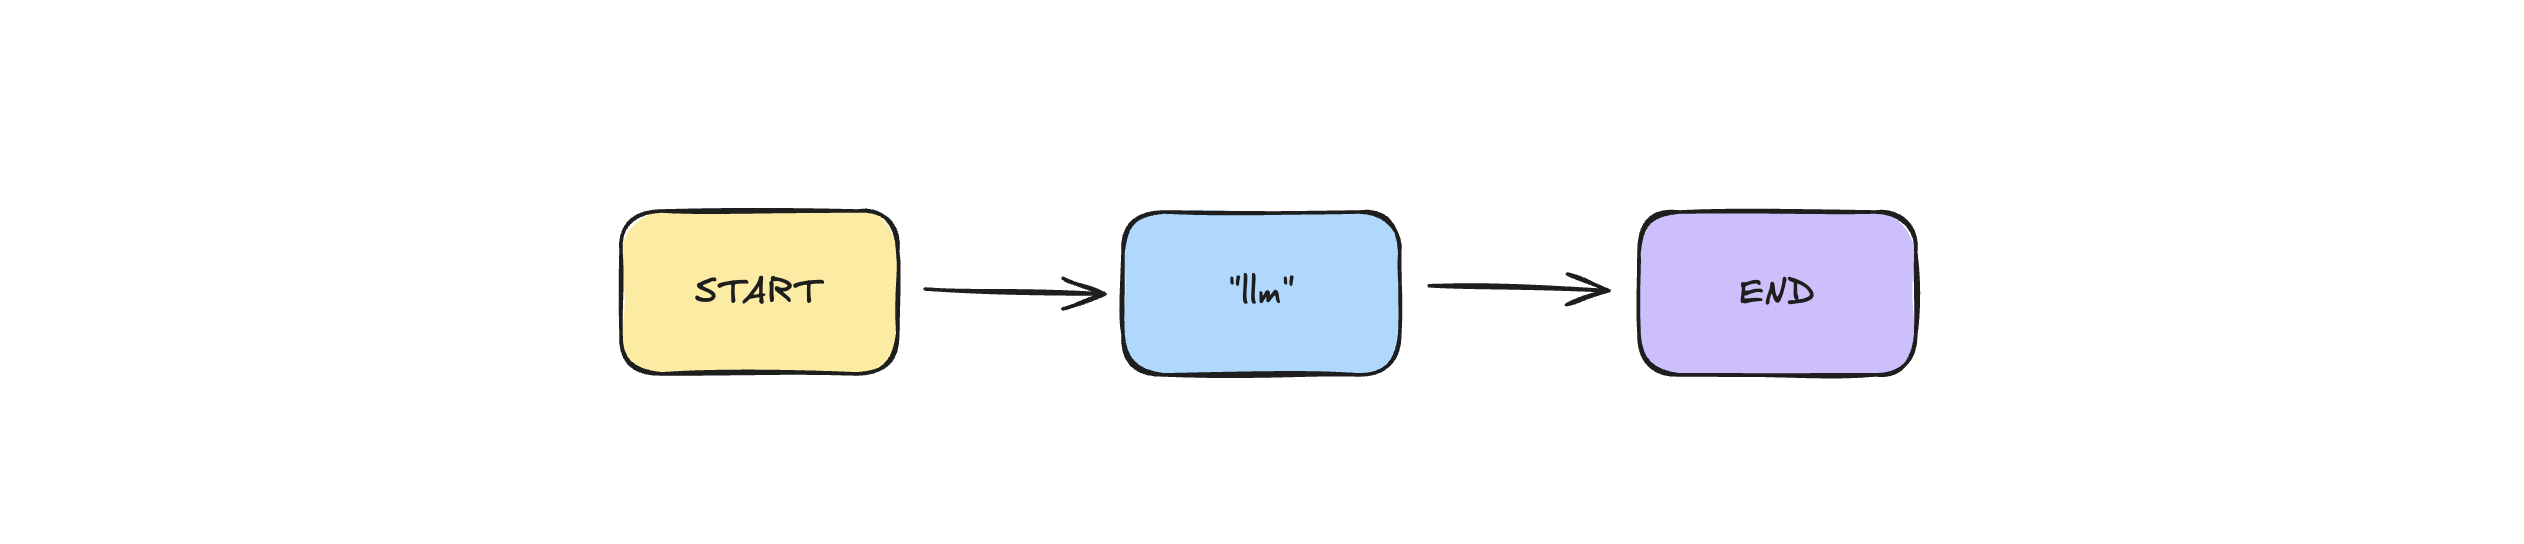


With the graph state up and running, it's time to define your first node and edges. You'll create a graph composed only of a `"llm"` node, which is simply and LLM, connected to a `START` and `END` node with edges.

`START` and `END` are fixed, built-in nodes indicating where a user input should enter the graph and a final response should exit it.

We'll use OpenAI's `"gpt-4o-mini"`, but any LangChain-compatible LLM would work here (with potentially differing performance). We've configured your environment so you don't need to specify an OpenAI API key.

**Define the `llm` to be used in the workflow and an `llm_node()` function to be triggered when the node is reached.**

In [13]:
import os
from langchain_openai import ChatOpenAI

# Define an OpenAI LLM
llm = ChatOpenAI(model="gpt-4o-mini", api_key=api_key)

# Takes the state, and appends the new messages to it
def llm_node(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

**Add the node and edges to the graph to create the linear workflow.**

In [14]:
# Create a node called "llm" that calls the llm_node function
graph_builder.add_node("llm", llm_node)

# Connect the "llm" node to the START and END of the graph
graph_builder.add_edge(START, "llm")
graph_builder.add_edge("llm", END)

# Compile the graph
graph = graph_builder.compile()

### 🖼️ Visualize your first graph

If you execute your graph object, it will display your graph as a visualization. Pretty neat, right?

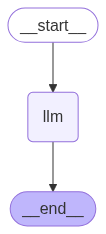

In [15]:
# Visualize your graph
graph

Let's have some fun with your first graph! 🚀

Run the code below to begin talking to it in real-time. Feel free to try different inputs by changing the message content.

Note: If this cell hangs, click the stop button next to the cell.

In [16]:
from langchain_core.messages import convert_to_messages


def pretty_print_message(message, indent=False):
    pretty_message = message.pretty_repr(html=True)
    if not indent:
        print(pretty_message)
        return

    indented = "\n".join("\t" + c for c in pretty_message.split("\n"))
    print(indented)


def pretty_print_messages(update, last_message=False):
    is_subgraph = False
    if isinstance(update, tuple):
        ns, update = update
        # skip parent graph updates in the printouts
        if len(ns) == 0:
            return

        graph_id = ns[-1].split(":")[0]
        print(f"Update from subgraph {graph_id}:")
        print("\n")
        is_subgraph = True

    for node_name, node_update in update.items():
        update_label = f"Update from node {node_name}:"
        if is_subgraph:
            update_label = "\t" + update_label

        print(update_label)
        print("\n")

        messages = convert_to_messages(node_update["messages"])
        if last_message:
            messages = messages[-1:]

        for m in messages:
            pretty_print_message(m, indent=is_subgraph)
        print("\n")

In [17]:
# from course_helper_functions import pretty_print_messages

for chunk in graph.stream(
    {"messages": [{"role": "user", "content": "Tell me about Apple Inc."}]}
):
    pretty_print_messages(chunk)

Update from node llm:


================================== Ai Message ==================================

Apple Inc. is an American multinational technology company headquartered in Cupertino, California. Founded on April 1, 1976, by Steve Jobs, Steve Wozniak, and Ronald Wayne, the company initially focused on designing and selling personal computers. Over the years, Apple has evolved into one of the world's most valuable and influential companies, known for its innovative products and services.

### Key Products and Services

1. **iPhone**: Launched in 2007, the iPhone is Apple's flagship smartphone and has significantly influenced modern mobile technology and design.

2. **iPad**: Introduced in 2010, the iPad is a line of tablet computers that has found applications in education, business, and entertainment.

3. **Mac**: Apple's line of personal computers includes various models such as the MacBook, iMac, and Mac Pro. The MacOS operating system powers these devices.

4. **Apple Watch

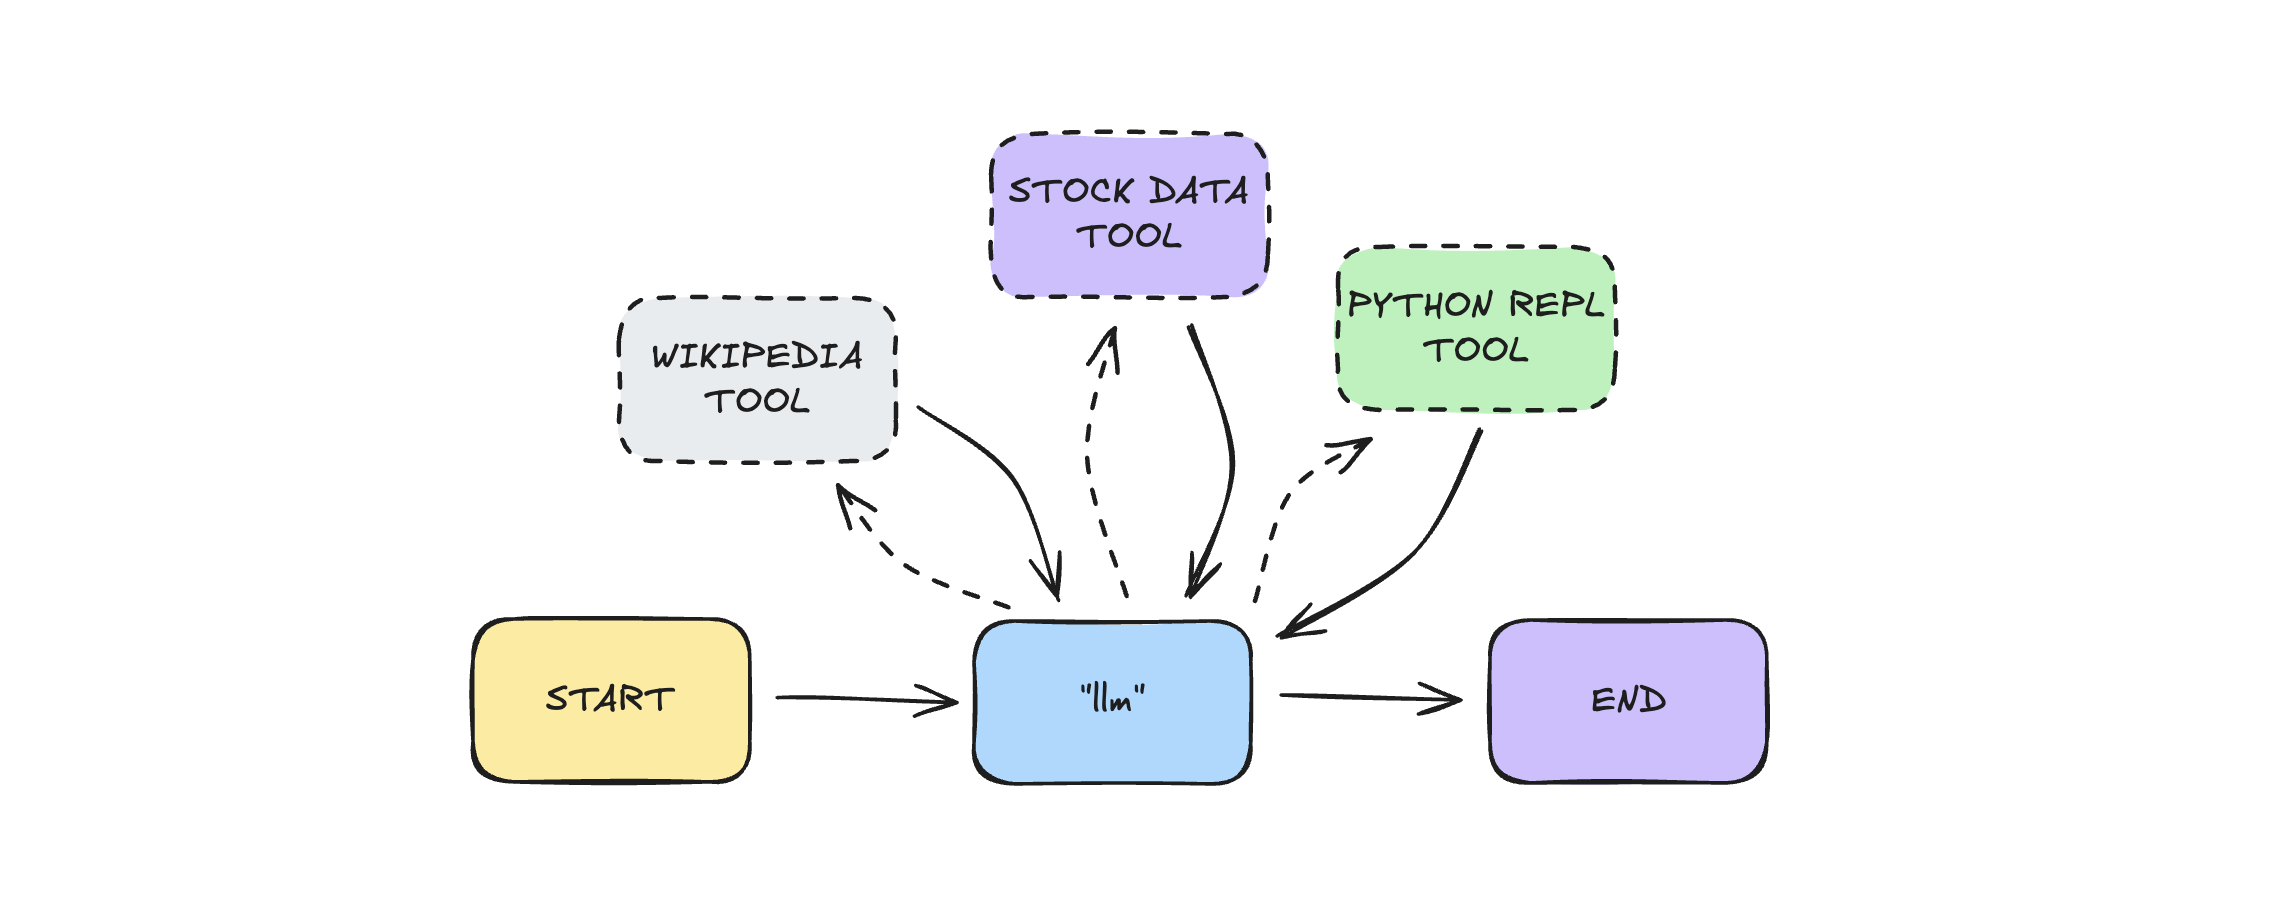

### 🔨 How can LLMs use tools?

Recall that you created three tools for the LLM to use:
1. `wikipedia_tool()`: Wikipedia search of company information.
2. `stock_data_tool()`: returns stock performance data from CSV files.
3. `python_repl_tool()`: runs Python code to generate plots.

In [18]:
from typing import Annotated
import wikipedia
from langchain_core.tools import tool
import pandas as pd
import os

@tool
def wikipedia_tool(
    query: Annotated[str, "The Wikipedia search to execute to find key summary information."],
):
    """Use this to search Wikipedia for factual information."""
    try:
        # Step 1: Search using query
        results = wikipedia.search(query)
        
        if not results:
            return "No results found on Wikipedia."
        
        # Step 2: Retrieve page title
        title = results[0]

        # Step 3: Fetch summary
        summary = wikipedia.summary(title, sentences=8, auto_suggest=False, redirect=True)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    return f"Successfully executed:\nWikipedia summary: {summary}"

@tool
def stock_data_tool(
    company_ticker: Annotated[str, "The ticker symbol of the company to retrieve their stock performance data."], 
    num_days: Annotated[int, "The number of business days of stock data required to respond to the user query."]
) -> str:
    """
    Use this to look-up stock performance data for companies to retrieve a table from a CSV. You may need to convert company names into ticker symbols to call this function, e.g, Apple Inc. -> AAPL, and you may need to convert weeks, months, and years, into days.
    """
    
    # Load the CSV for the company requested
    file_path = f"data/{company_ticker}.csv"

    if os.path.exists(file_path) is False:
        return f"Sorry, but data for company {company_ticker} is not available. Please try Apple, Amazon, Meta, Microsoft, Netflix, or Tesla."
    
    stock_df = pd.read_csv(file_path, index_col='Date', parse_dates=True)

    # Ensure the index is in date format
    stock_df.index = stock_df.index.date
    
    # Maximum num_days supported by the dataset
    max_num_days = (stock_df.index.max() - stock_df.index.min()).days
    
    if num_days > max_num_days:
        return "Sorry, but this time period exceeds the data available. Please reduce it to continue."
    
    # Get the most recent date in the DataFrame
    final_date = stock_df.index.max()

    # Filter the DataFrame to get the last num_days of stock data
    filtered_df = stock_df[stock_df.index > (final_date - pd.Timedelta(days=num_days))]

    return f"Successfully executed the stock performance data retrieval tool to retrieve the last *{num_days} days* of data for company **{company_ticker}**:\n\n{filtered_df.to_markdown()}"

from langchain_experimental.utilities import PythonREPL

repl = PythonREPL()

@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user. The chart should be displayed using `plt.show()`."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    return f"Successfully executed the Python REPL tool.\n\nPython code executed:\n\`\`\`python\n{code}\n\`\`\`\n\nCode output:\n\`\`\`\n{result}\`\`\`"

### 🧰 Inspecting yout tools

These tools, when fully integrated into the graph, will be available for the chatbot to call depending on whether it determines a tool is required. But how does it do this?

Each tool created with the `@tool` decorator has a description, which is made available to the model when the tools and model are binded together.

**Print the `.name` and `.description` attributes for each `tool`. What do you notice about these descriptions?**

In [19]:
# Loop through the tools and extract the .name and .description attributes
for tool in [wikipedia_tool, stock_data_tool, python_repl_tool]:
    print(f"The description for {tool.name}:\n> {tool.description}\n")

The description for wikipedia_tool:
> Use this to search Wikipedia for factual information.

The description for stock_data_tool:
> Use this to look-up stock performance data for companies to retrieve a table from a CSV. You may need to convert company names into ticker symbols to call this function, e.g, Apple Inc. -> AAPL, and you may need to convert weeks, months, and years, into days.

The description for python_repl_tool:
> Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user. The chart should be displayed using `plt.show()`.



The docstrings in the tools became the tool descriptions! This means that a description that makes it clear to the model when and how to use the tool is crucial in the model's decision-making process.

**Complete the code to define a `tools` list and bind them to the LLM. Invoke this binded LLM inside the `llm_node()` function.**

In [20]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

# Add three tools to the list: wikipedia_tool, stock_data_tool, and python_repl_tool
tools = [wikipedia_tool, stock_data_tool, python_repl_tool]

llm = ChatOpenAI(model="gpt-4o-mini", api_key=api_key)

# Tell the LLM which tools it can call
llm_with_tools = llm.bind_tools(tools)

# Invoke llm_with_tools in the llm_node() function
def llm_node(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

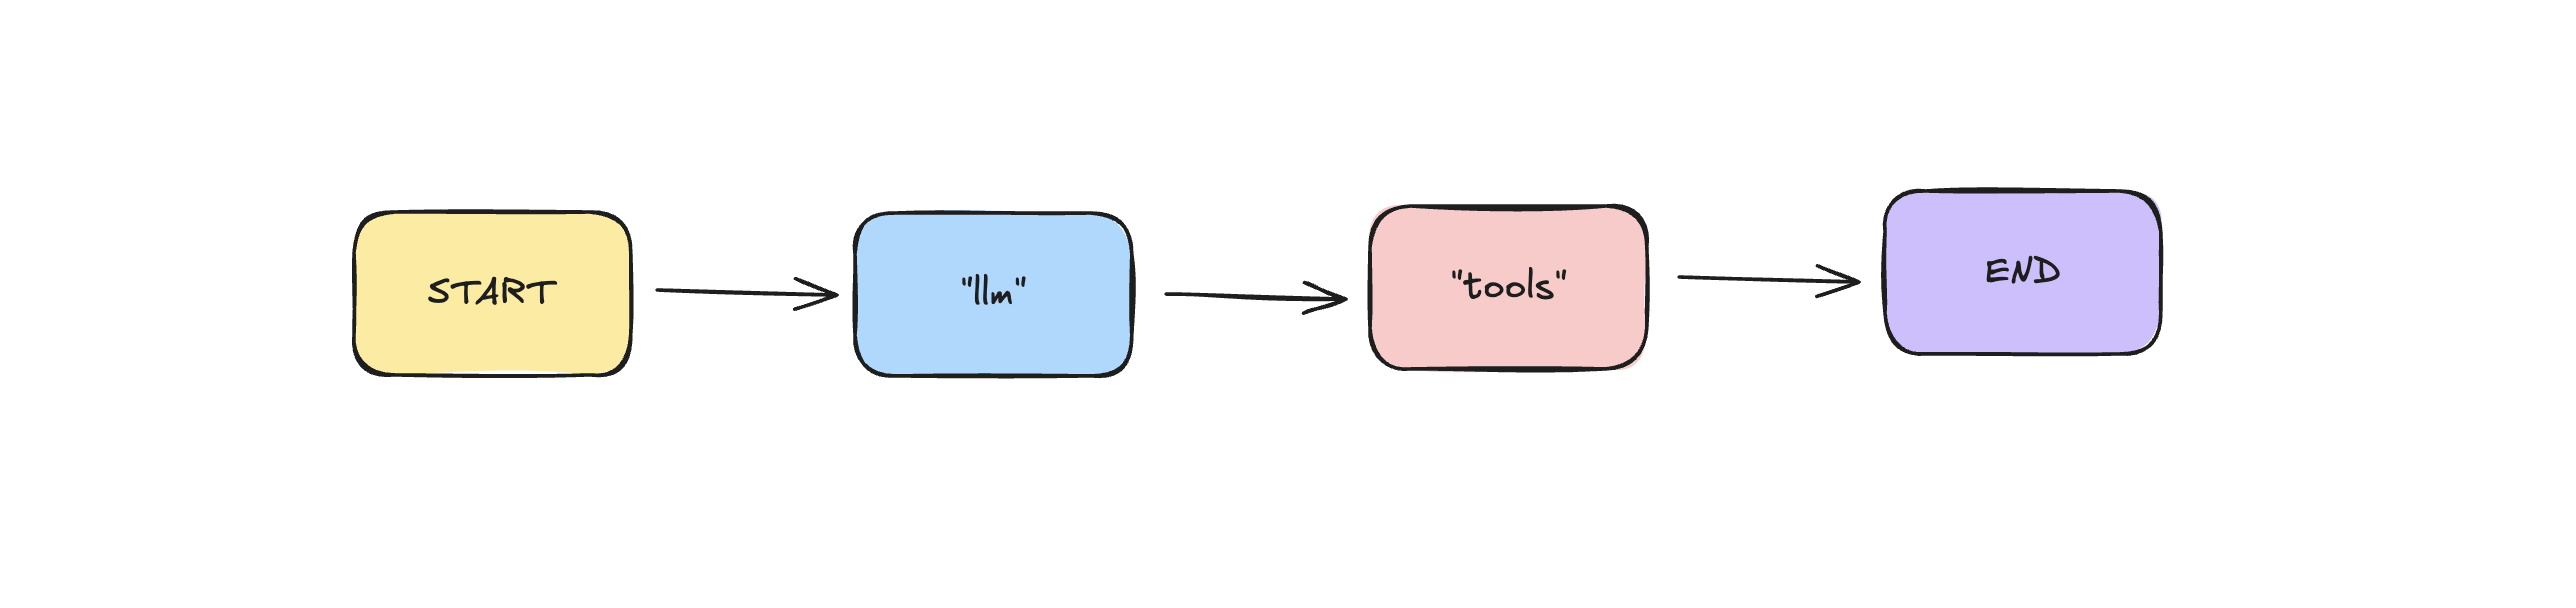

To actually run these tools in the graph, tools need to be assigned their own node.

You can create a **tool node** using the `ToolNode` class, add it to the graph with `.add_node()`, and connect the node to the graph with an edge as you did with the `"llm"` node.

In [21]:
from langgraph.prebuilt import ToolNode

graph_builder.add_node("llm", llm_node)

# Create a tool node containing the three tools you defined
tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

# Create edges to represent the linear workflow
graph_builder.add_edge(START, "llm")
graph_builder.add_edge("llm", "tools")
graph_builder.add_edge("tools", END)

graph = graph_builder.compile()

Now re-run the visualization code to see your updated graph! 🚀

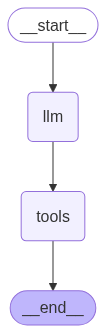

In [22]:
# Visualize your graph
graph

Great job! The input is entering the chatbot node, then entering the tool node to run the tools, before finishing.

Similar to before, run the code below to begin interacting with your (now tool-powered) agent. Specifically, try running these inputs and note down what you see:

1. Tell me about Apple Inc.
2. AAPL stock price.
3. Plot an Open price time-series of AAPL.
4. My name is `<Insert your name>`.

In [23]:
#from course_helper_functions import pretty_print_messages

for chunk in graph.stream(
    {"messages": [{"role": "user", "content": "Tell me about Apple Inc."}]}
):
    pretty_print_messages(chunk)

Update from node llm:


================================== Ai Message ==================================
Tool Calls:
  wikipedia_tool (call_26gpLR8324rEBmKM7kMAFcd3)
 Call ID: call_26gpLR8324rEBmKM7kMAFcd3
  Args:
    query: Apple Inc.


Update from node tools:


================================= Tool Message =================================
Name: wikipedia_tool

Successfully executed:
Wikipedia summary: Apple Inc. is an American multinational corporation and technology company headquartered in Cupertino, California, in Silicon Valley. It is best known for its consumer electronics, software, and services. Founded in 1976 as Apple Computer Company by Steve Jobs, Steve Wozniak and Ronald Wayne, the company was incorporated by Jobs and Wozniak as Apple Computer, Inc. the following year. It was renamed Apple Inc. in 2007 as the company had expanded its focus from computers to consumer electronics. Apple is the largest technology company by revenue, with US$391.04 billion in the 2024 fisca

In [ ]:
#from course_helper_functions import pretty_print_messages

for chunk in graph.stream(
    {"messages": [{"role": "user", "content": "AAPL stock price."}]}
):
    pretty_print_messages(chunk)

In [ ]:
#from course_helper_functions import pretty_print_messages

for chunk in graph.stream(
    {"messages": [{"role": "user", "content": "Plot an Open price time-series of AAPL."}]}
):
    pretty_print_messages(chunk)

In [ ]:
#from course_helper_functions import pretty_print_messages

for chunk in graph.stream(
    {"messages": [{"role": "user", "content": "My name is Sacha."}]}
):
    pretty_print_messages(chunk)

### 💡 What did we learn here?

Congratulations on making and conversing with your first agent! 🤖 You learned quite a bit in this preliminary example, and you may have already spotted a few areas of improvement:

1. The plotting function didn't work&mdash;this is because this tool relies on another tool's output (the stock performance data tool). Without this data, the agent is forced to do something else. Later in the course, we'll use multiple agents to coordinate this.
2. In this example, the chatbot node was always directed into the tools node, regardless of whether the user input requires a tool call or not. In the case of sending your name to the LLM, it stopped when it realized that no tools were required instead of falling back to a standard chatbot response. Let's improve this by swapping the vanilla edges (created with `.add_edge()`) with a ***conditional edge***!

## Chapter 2 - Multi-Agents with LangGraph

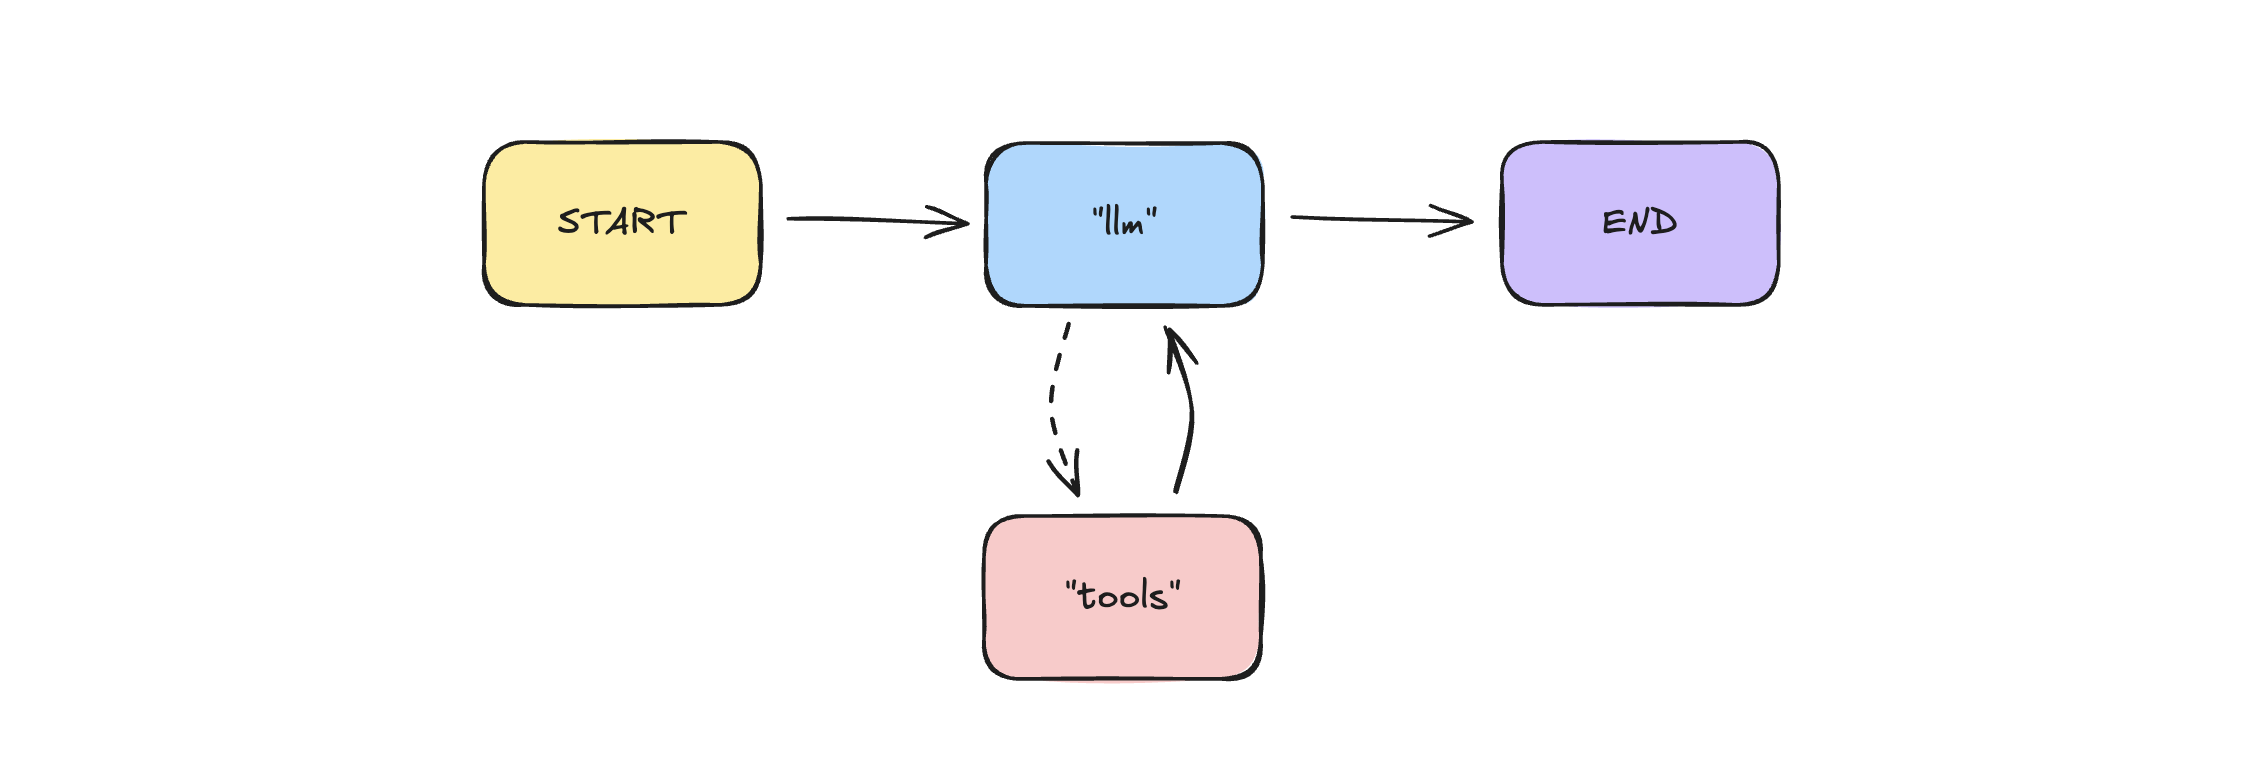

### 🪚 Making tools optional

In the last exercise, you saw how the linear workflow directed all LLM outputs into the tool node, irrespective of whether a tool call was required. Let's change this so our system can handle user inputs that don't require tool calls.

In [24]:
from typing import Annotated
import wikipedia
from langchain_core.tools import tool
import pandas as pd
import os

@tool
def wikipedia_tool(
    query: Annotated[str, "The Wikipedia search to execute to find key summary information."],
):
    """Use this to search Wikipedia for factual information."""
    try:
        # Step 1: Search using query
        results = wikipedia.search(query)
        
        if not results:
            return "No results found on Wikipedia."
        
        # Step 2: Retrieve page title
        title = results[0]

        # Step 3: Fetch summary
        summary = wikipedia.summary(title, sentences=8, auto_suggest=False, redirect=True)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    return f"Successfully executed:\nWikipedia summary: {summary}"

@tool
def stock_data_tool(
    company_ticker: Annotated[str, "The ticker symbol of the company to retrieve their stock performance data."], 
    num_days: Annotated[int, "The number of business days of stock data required to respond to the user query."]
) -> str:
    """
    Use this to look-up stock performance data for companies to retrieve a table from a CSV. You may need to convert company names into ticker symbols to call this function, e.g, Apple Inc. -> AAPL, and you may need to convert weeks, months, and years, into days.
    """
    
    # Load the CSV for the company requested
    file_path = f"data/{company_ticker}.csv"

    if os.path.exists(file_path) is False:
        return f"Sorry, but data for company {company_ticker} is not available. Please try Apple, Amazon, Meta, Microsoft, Netflix, or Tesla."
    
    stock_df = pd.read_csv(file_path, index_col='Date', parse_dates=True)

    # Ensure the index is in date format
    stock_df.index = stock_df.index.date
    
    # Maximum num_days supported by the dataset
    max_num_days = (stock_df.index.max() - stock_df.index.min()).days
    
    if num_days > max_num_days:
        return "Sorry, but this time period exceeds the data available. Please reduce it to continue."
    
    # Get the most recent date in the DataFrame
    final_date = stock_df.index.max()

    # Filter the DataFrame to get the last num_days of stock data
    filtered_df = stock_df[stock_df.index > (final_date - pd.Timedelta(days=num_days))]

    return f"Successfully executed the stock performance data retrieval tool to retrieve the last *{num_days} days* of data for company **{company_ticker}**:\n\n{filtered_df.to_markdown()}"

from langchain_experimental.utilities import PythonREPL

repl = PythonREPL()

@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user. The chart should be displayed using `plt.show()`."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    return f"Successfully executed the Python REPL tool.\n\nPython code executed:\n\`\`\`python\n{code}\n\`\`\`\n\nCode output:\n\`\`\`\n{result}\`\`\`"

### ❓Introducing conditional edges

One of the problems with our current agentic system is that the chatbot node was always directed into the tools node, regardless of whether the user input requires the tools or not. This means that the LLM isn't really making a decision, as there is no other choice but to proceed.

LangGraph provides ***conditional edges***, which are like splits in the workflow where the agent can choose which way to go.

In [25]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

# Add three tools to the list: wikipedia_tool, stock_data_tool, and python_repl_tool
tools = [wikipedia_tool, stock_data_tool, python_repl_tool]

llm = ChatOpenAI(model="gpt-4o-mini", api_key=api_key)

# Tell the LLM which tools it can call
llm_with_tools = llm.bind_tools(tools)

def llm_node(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

### ➕ Adding the conditional edge

Now to build the graph! We need to build `"llm"` and `"tools"` nodes as before, but this time, you need to add a conditional edge to the `"llm"` node, so it can use the `tools_condition` function to decide whether to trigger the tools or end. `"tools"` must also be connected back to `"llm"` so the LLM can decide whether it is able to end the task or trigger another tool.

The `.add_conditional_edges()` method is similar to `.add_edge()`, taking a source node to start at, but then it takes a function to evaluate how to proceed, and a dictionary indicating which nodes to continue to, depending on the evaluation.

The following code uses the built-in `tools_condition`, which asks the model to decide if a tool is required; if so, it moves to the `"tools"` node, if not, it moves to the `END` node (which is named `__end__`).

```py
graph_builder.add_conditional_edges(START, tools_condition, {"tools", END})
```

**Complete the code to define the graph containing conditional edges from the LLM node to the tool node.**

In [26]:
from langgraph.prebuilt import ToolNode, tools_condition

# Create the llm and tools nodes
graph_builder.add_node("llm", llm_node)
tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

# Add the edges
graph_builder.add_edge(START, "llm")
graph_builder.add_conditional_edges("llm", tools_condition, ["tools", END])
graph_builder.add_edge("tools", "llm")

graph = graph_builder.compile()

Run the code to visualize the updated graph!

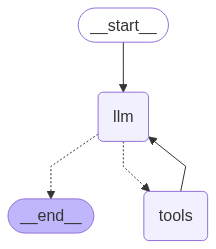

In [27]:
# Visualize your graph
graph

Nicely done! The input is enters the chatbot node, which then decides whether a tool needs to be triggered. If it is required, the tools are called; if not, the chatbot responds using its knowledge and ends the interaction.

Try re-running the same inputs as before to spot the difference!

1. Tell me about Apple Inc.
2. AAPL stock price.
3. My name is `<Insert your name>`.
4. Plot an Open price time-series of AAPL.

In [28]:
for chunk in graph.stream(
    {"messages": [{"role": "user", "content": "Tell me about Apple Inc."}]}
):
    pretty_print_messages(chunk)

Update from node llm:


================================== Ai Message ==================================
Tool Calls:
  wikipedia_tool (call_DVqVLruwqHsv76VCAOKLeq0m)
 Call ID: call_DVqVLruwqHsv76VCAOKLeq0m
  Args:
    query: Apple Inc.


Update from node tools:


================================= Tool Message =================================
Name: wikipedia_tool

Successfully executed:
Wikipedia summary: Apple Inc. is an American multinational corporation and technology company headquartered in Cupertino, California, in Silicon Valley. It is best known for its consumer electronics, software, and services. Founded in 1976 as Apple Computer Company by Steve Jobs, Steve Wozniak and Ronald Wayne, the company was incorporated by Jobs and Wozniak as Apple Computer, Inc. the following year. It was renamed Apple Inc. in 2007 as the company had expanded its focus from computers to consumer electronics. Apple is the largest technology company by revenue, with US$391.04 billion in the 2024 fisca

In [ ]:
for chunk in graph.stream(
    {"messages": [{"role": "user", "content": "AAPL stock price."}]}
):
    pretty_print_messages(chunk)

In [ ]:

for chunk in graph.stream(
    {"messages": [{"role": "user", "content": "My name is Sacha."}]}
):
    pretty_print_messages(chunk)

Update from node llm:


================================== Ai Message ==================================
Tool Calls:
  stock_data_tool (call_CS4C4lVdKhmFvTI6sfyNIrw3)
 Call ID: call_CS4C4lVdKhmFvTI6sfyNIrw3
  Args:
    company_ticker: AAPL
    num_days: 30


Update from node tools:


================================= Tool Message =================================
Name: stock_data_tool

Successfully executed the stock performance data retrieval tool to retrieve the last *30 days* of data for company **AAPL**:

|            | Close/Last   |    Volume | Open     | High      | Low       |
|:-----------|:-------------|----------:|:---------|:----------|:----------|
| 2025-05-28 | $200.42      |  45339680 | $200.59  | $202.73   | $199.90   |
| 2025-05-27 | $200.21      |  56288480 | $198.30  | $200.74   | $197.43   |
| 2025-05-23 | $195.27      |  78432920 | $193.665 | $197.70   | $193.46   |
| 2025-05-22 | $201.36      |  46742410 | $200.71  | $202.75   | $199.70   |
| 2025-05-21 | $202.09 

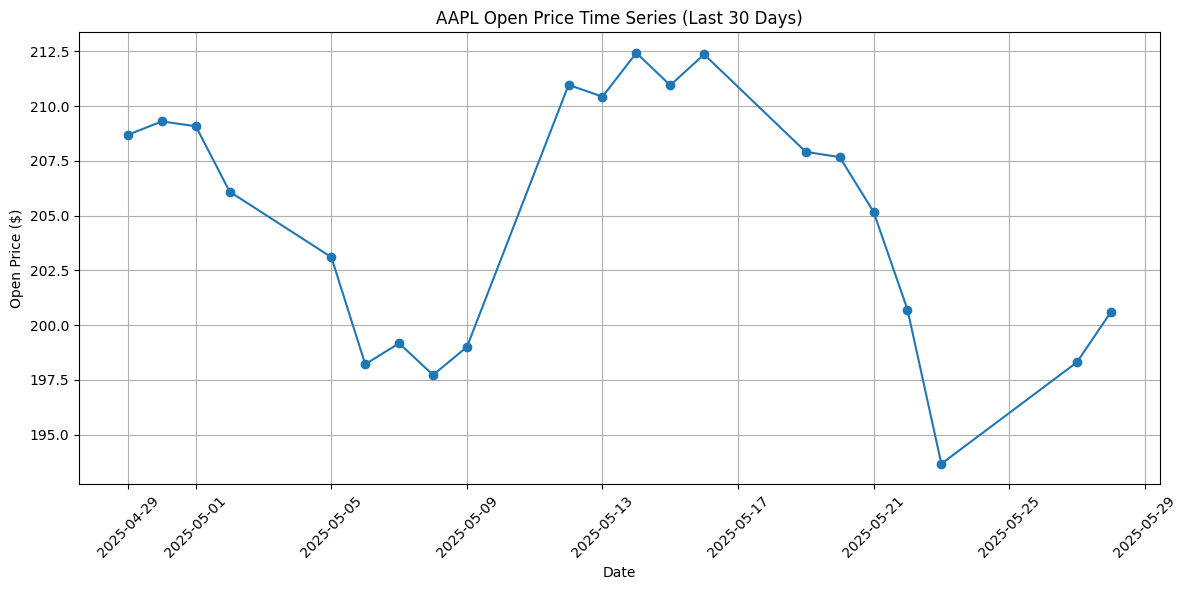

Update from node tools:


================================= Tool Message =================================
Name: python_repl_tool

Successfully executed the Python REPL tool.

Python code executed:
\`\`\`python
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Data from the stock performance
data = {
    'Date': [
        '2025-05-28', '2025-05-27', '2025-05-23', '2025-05-22', '2025-05-21',
        '2025-05-20', '2025-05-19', '2025-05-16', '2025-05-15', '2025-05-14',
        '2025-05-13', '2025-05-12', '2025-05-09', '2025-05-08', '2025-05-07',
        '2025-05-06', '2025-05-05', '2025-05-02', '2025-05-01', '2025-04-30',
        '2025-04-29'
    ],
    'Open': [
        200.59, 198.3, 193.665, 200.71, 205.17,
        207.67, 207.91, 212.36, 210.95, 212.43,
        210.43, 210.97, 199.0, 197.72, 199.17,
        198.21, 203.1, 206.09, 209.08, 209.3,
        208.693
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

df['Date'] = pd.to_datetime(df['Date'

In [29]:
for chunk in graph.stream(
    {"messages": [{"role": "user", "content": "Plot an Open price time-series of AAPL."}]}
):
    pretty_print_messages(chunk)

# One-line agents

Up until this point, you've used LangGraph's low-level syntax for defining individual nodes and edges and building-up the graph component-by-component. This can continue to serve you well as you progress to multi-modal systems, but for faster experimentation, switching to LangGraph's pre-built components can be a useful option.

LangGraph's `create_react_agent()` function allows you to quickly instantiate a tool-calling agent from an LLM and a list of tools!

LangGraph's `create_react_agent()` function allows you to quickly instantiate a tool-calling agent from an LLM and a list of tools!

In [30]:
from langgraph.prebuilt import create_react_agent
from langchain_openai import ChatOpenAI

# Add three tools to the list: wikipedia_tool, stock_data_tool, and python_repl_tool
tools = [wikipedia_tool, stock_data_tool, python_repl_tool]

llm = ChatOpenAI(model="gpt-4o-mini", api_key=api_key)

# Create an agent using the create_react_agent function
prompt = """
You are an assistant for research and analysis of Fortune 500 companies. You have access to three tools:
- A Wikipedia tool for retrieving factual summary information about companies
- A stock performance data tool for retrieving stock price information from local CSV files
- A Python tool for executing Python code, which is to be used for creating stock performance visualizations
"""

# Create an agent using the create_react_agent function
agent = create_react_agent(
    llm,
    tools=tools,
    name="financial_assistent",
    prompt=prompt)

This `agent` object is an already-compiled graph, so it can be visualized and interacted with in the same way as your previous graph to verify its equivalence:

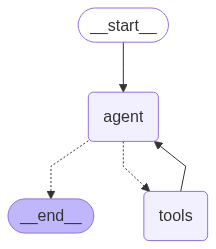

In [31]:
# Visualize your graph
agent

Here are the same prompts you tried with your graph with the conditional edge:

- Tell me about Apple Inc.
- AAPL stock price.
- My name is ...
- Plot an Open price time-series of AAPL.

Update from node agent:


================================== Ai Message ==================================
Name: financial_assistent
Tool Calls:
  wikipedia_tool (call_9skbxrJZSZY47FmbWrgsZyFe)
 Call ID: call_9skbxrJZSZY47FmbWrgsZyFe
  Args:
    query: Tesla Inc CEO
  stock_data_tool (call_0fgkhQBVwpku29ILGBAXBSsF)
 Call ID: call_0fgkhQBVwpku29ILGBAXBSsF
  Args:
    company_ticker: TSLA
    num_days: 30


Update from node tools:


================================= Tool Message =================================
Name: stock_data_tool

Successfully executed the stock performance data retrieval tool to retrieve the last *30 days* of data for company **TSLA**:

|            | Close/Last   |    Volume | Open     | High      | Low       |
|:-----------|:-------------|----------:|:---------|:----------|:----------|
| 2025-05-28 | $356.90      |  91404310 | $364.84  | $365.00   | $355.91   |
| 2025-05-27 | $362.89      | 120146400 | $347.35  | $363.79   | $347.32   |
| 2025-05-23 | $339.34     

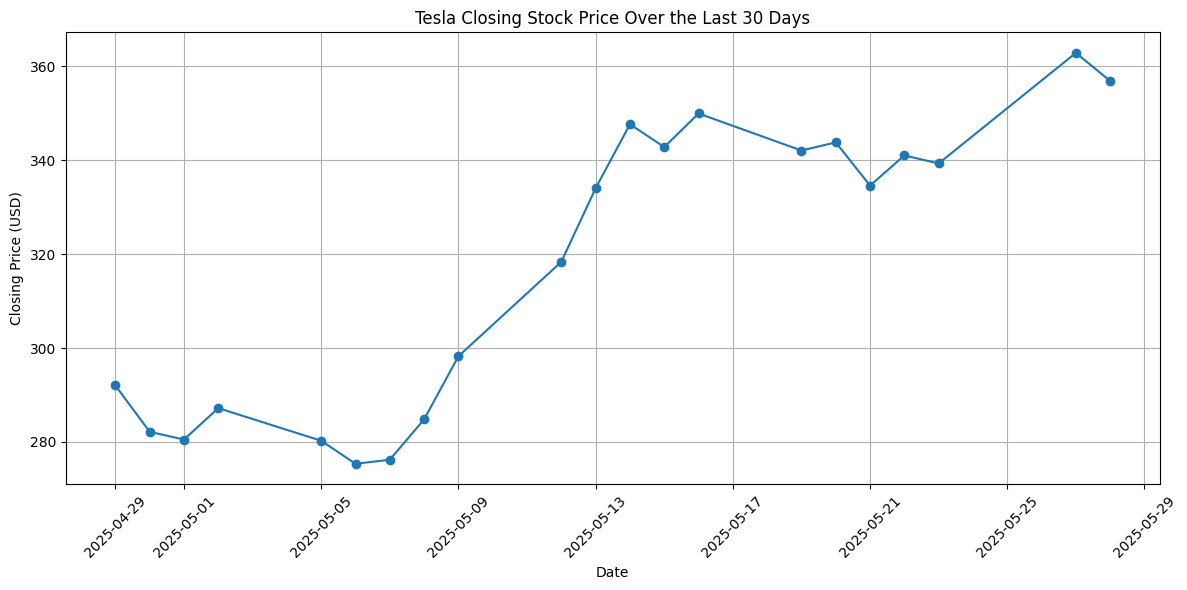

Update from node tools:


================================= Tool Message =================================
Name: python_repl_tool

Successfully executed the Python REPL tool.

Python code executed:
\`\`\`python
import pandas as pd
import matplotlib.pyplot as plt

# Tesla's stock data for the last 30 days
stock_data = {
    'Date': ['2025-05-28', '2025-05-27', '2025-05-23', '2025-05-22', '2025-05-21', '2025-05-20',
             '2025-05-19', '2025-05-16', '2025-05-15', '2025-05-14', '2025-05-13', '2025-05-12',
             '2025-05-09', '2025-05-08', '2025-05-07', '2025-05-06', '2025-05-05', '2025-05-02',
             '2025-05-01', '2025-04-30', '2025-04-29'],
    'Close': [356.90, 362.89, 339.34, 341.04, 334.62, 343.82, 342.09, 349.98, 342.82, 347.68, 
               334.07, 318.38, 298.26, 284.82, 276.22, 275.35, 280.26, 287.21, 280.52, 282.16, 292.03]
}

# Create a DataFrame
df = pd.DataFrame(stock_data)

# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Plottin

In [32]:
for chunk in agent.stream(
    {"messages": [{"role": "user", "content": "Tell me Tesla's current CEO, their latest stock price, and generate a plot of the closing price with the most up-to-date data you have available."}]}
):
    pretty_print_messages(chunk)

As we move into creating multi-agent systems, we'll use `create_react_agent()` so we can focus on connecting the agents together rather than creating each one individually. Once you've finished the course, you could even try refactoring your final multi-agent system using the lower-level syntax.

### 💡 What did we learn here?

- The `create_react_agent()` function is a useful utility for quickly creating a tool-calling agent, and we'll use this as we switch to creating multi-agent systems.

### Section 2.2 - Multi-Agent

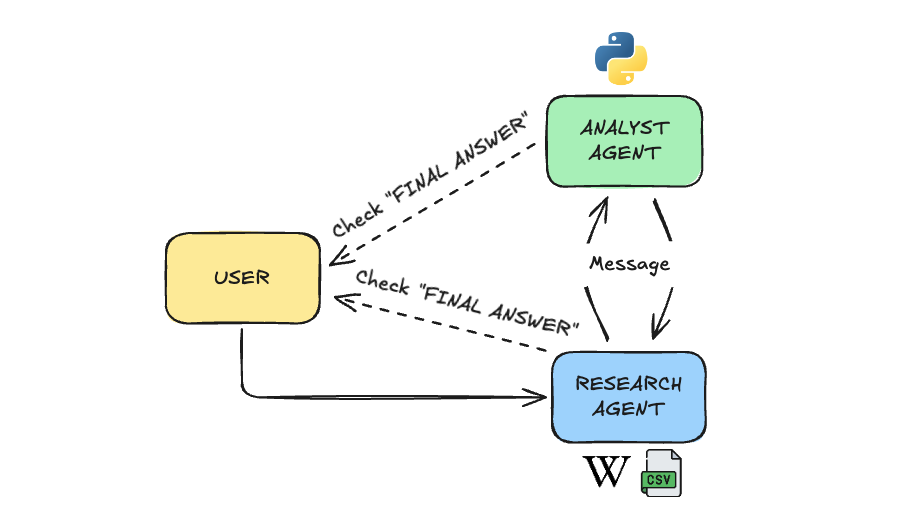


### 🐝 Starting the swarm
Let's upgrade our single-agent system to multi-agent system! We'll start with two agents arranged as a **swarm**: a researcher, that can trigger the Wikipedia tool (`wikipedia_tool()`), and a data analyst, that can trigger the stock performance data and Python REPL tools (`stock_data_tool()` and `python_repl_tool()`, respectively).

To get our swarm multi-agent started, we'll create a handoff tool for each agent, so it can choose to use its original toolset, or handoff to the other agent.

These tools, like the other tools we've created, need to have clear descriptions so the agent can determine the most appropriate action.

**Complete the code to define a handoff tool for each agent.**

In [44]:
from langchain_openai import ChatOpenAI
from langgraph_swarm import create_handoff_tool

llm = ChatOpenAI(model="gpt-4o-mini", api_key=api_key)

# Create a handoff tool for analyst -> researcher
transfer_to_researcher = create_handoff_tool(
    agent_name="researcher",
    description="Transfer user to the analyst assistant, who can create visualizations of provided data.",
)

# Create a handoff tool for researcher -> analyst
transfer_to_analyst = create_handoff_tool(
    agent_name="analyst",
    description="Transfer user to the researcher assistant, who can retrieve Wikipedia summaries or load stock performance data from CSV files.",
)

These handoff tools can then be added to the tool list like any other tool! To create both of these agents, we'll use LangGraph's `create_react_agent()` function. You can create these agents using the low-level LangGraph node/edge syntax you used earlier, but as we move to the multi-agent case, this code can get quite long.

**Complete the code to define a research and analyst agent with access to the new handoff tools.**

In [45]:
from langgraph.prebuilt import create_react_agent

# Create a researcher agent with access to two tools + the handoff tool
research_agent = create_react_agent(
    llm,
    tools=[wikipedia_tool, stock_data_tool, transfer_to_analyst],
    prompt="You provide summaries from Wikipedia, and can load raw, numerical stock performance data from CSV files.",
    name="researcher"
)

# Create a analyst agent with access to one tool + the handoff tool
analyst_agent = create_react_agent(
    llm,
    [python_repl_tool, transfer_to_researcher],
    prompt="You generate plots of stock performance data provided by another assistant.",
    name="analyst"
)

Now to bring the agents together! We'll create a short-term memory so the graph can track which agents have been called, and then create the swarm using the handy `create_swarm()` function, setting the default agent to `"researcher"`.

The LangGraph `InMemorySaver` class is equivalent to the `State` implementation you wrote for the single-agent case. For multi-agents, having a memory is crucial to enable successful collaboration between agents.

The memory is past to the `checkpointer` argument of `.compile()`, and a config is required that has been provided for you.

**Complete the code to create the swarm multi-agent system, setting the default agent to `"researcher"`.**

In [46]:
from langgraph_swarm import create_swarm
from langgraph.checkpoint.memory import InMemorySaver

config = {"configurable": {"thread_id": "1", "user_id": "1"}}
checkpointer = InMemorySaver()

# Create the swarm multi-agent graph and compile it
swarm = create_swarm(
    agents=[research_agent, analyst_agent],
    default_active_agent="researcher"
).compile(checkpointer=checkpointer)

Run the two code blocks below to visualize your multi-agent network graph and play around with your system! 🚀

Try re-running the same inputs as before to spot the difference!

- Tell me about Apple Inc.
- AAPL stock price.
- My name is <Insert your name>.
- Plot an Open price time-series of AAPL.

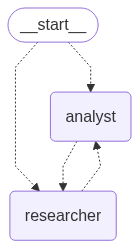

In [47]:
# Visualize your graph
swarm

### 🧪 Testing user inputs
Time to call the supervisor agent to test out how it performs!

- Who is Apple's CEO?
- Has Tesla's share price increased over the last month?
- Plot a chart of the Google's share price over the last month.

In [39]:
for chunk in swarm.stream(
    {"messages": [{"role": "user", "content": "Who is Apple's CEO?"}]}, config
):
    pretty_print_messages(chunk)

Update from node researcher:


================================ Human Message =================================

Who is Apple's CEO?
================================== Ai Message ==================================
Name: researcher
Tool Calls:
  wikipedia_tool (call_umB2l47ObWhzptlfubXn7xOL)
 Call ID: call_umB2l47ObWhzptlfubXn7xOL
  Args:
    query: Apple Inc. CEO
================================= Tool Message =================================
Name: wikipedia_tool

Successfully executed:
Wikipedia summary: Between 1978 and 2007, there were a number of legal disputes between Apple Corps (owned by the Beatles) and the computer manufacturer Apple Computer (now Apple Inc.) over competing trademark rights, specifically over the use of the name "Apple" and their respective logos which consist of a profile of an apple. Apple Inc. paid Apple Corps. over three settlements: $80,000 in 1978, $26.5 million in 1991, and $500 million in 2007, when Apple Inc. acquired all the trademarks related to "Ap

In [42]:
for chunk in swarm.stream(
    {"messages": [{"role": "user", "content": "Has Tesla's share price increased over the last month?"}]}, config
):
    pretty_print_messages(chunk)

Update from node researcher:


================================ Human Message =================================

Who is Apple's CEO?
================================== Ai Message ==================================
Name: researcher
Tool Calls:
  wikipedia_tool (call_umB2l47ObWhzptlfubXn7xOL)
 Call ID: call_umB2l47ObWhzptlfubXn7xOL
  Args:
    query: Apple Inc. CEO
================================= Tool Message =================================
Name: wikipedia_tool

Successfully executed:
Wikipedia summary: Between 1978 and 2007, there were a number of legal disputes between Apple Corps (owned by the Beatles) and the computer manufacturer Apple Computer (now Apple Inc.) over competing trademark rights, specifically over the use of the name "Apple" and their respective logos which consist of a profile of an apple. Apple Inc. paid Apple Corps. over three settlements: $80,000 in 1978, $26.5 million in 1991, and $500 million in 2007, when Apple Inc. acquired all the trademarks related to "Ap

Update from node researcher:


================================ Human Message =================================

Plot a chart of the Netflix share price over the last month.
================================== Ai Message ==================================
Name: researcher
Tool Calls:
  stock_data_tool (call_PJHYYkqpoNADnRIPgXFp9ZIm)
 Call ID: call_PJHYYkqpoNADnRIPgXFp9ZIm
  Args:
    company_ticker: NFLX
    num_days: 20
================================= Tool Message =================================
Name: stock_data_tool

Successfully executed the stock performance data retrieval tool to retrieve the last *20 days* of data for company **NFLX**:

|            | Close/Last   |   Volume | Open      | High       | Low        |
|:-----------|:-------------|---------:|:----------|:-----------|:-----------|
| 2025-05-28 | $1208.55     |  1855850 | $1210.27  | $1215.9101 | $1206.02   |
| 2025-05-27 | $1211.57     |  2920469 | $1195.33  | $1211.77   | $1193.09   |
| 2025-05-23 | $1185.39     | 

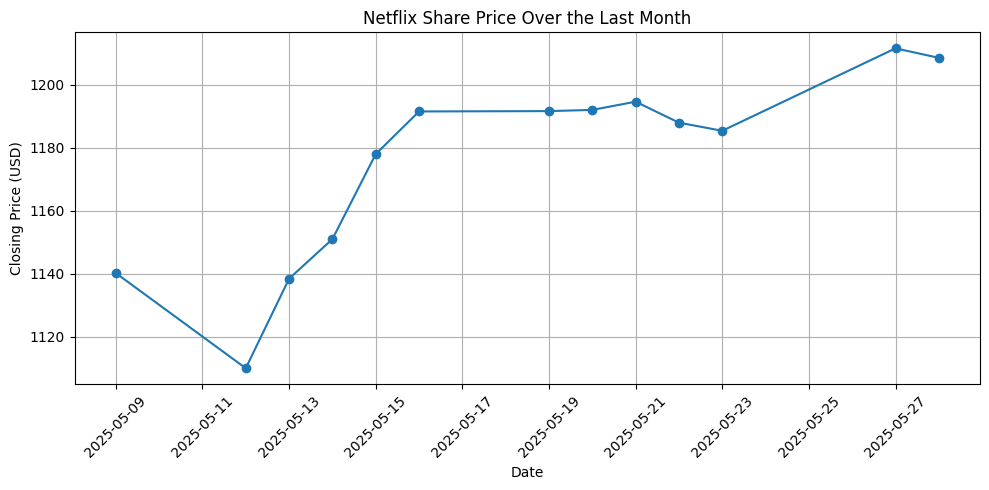

Update from node analyst:


================================ Human Message =================================

Plot a chart of the Netflix share price over the last month.
================================== Ai Message ==================================
Name: researcher
Tool Calls:
  stock_data_tool (call_PJHYYkqpoNADnRIPgXFp9ZIm)
 Call ID: call_PJHYYkqpoNADnRIPgXFp9ZIm
  Args:
    company_ticker: NFLX
    num_days: 20
================================= Tool Message =================================
Name: stock_data_tool

Successfully executed the stock performance data retrieval tool to retrieve the last *20 days* of data for company **NFLX**:

|            | Close/Last   |   Volume | Open      | High       | Low        |
|:-----------|:-------------|---------:|:----------|:-----------|:-----------|
| 2025-05-28 | $1208.55     |  1855850 | $1210.27  | $1215.9101 | $1206.02   |
| 2025-05-27 | $1211.57     |  2920469 | $1195.33  | $1211.77   | $1193.09   |
| 2025-05-23 | $1185.39     |  21

In [48]:
for chunk in swarm.stream(
    {"messages": [{"role": "user", "content": "Plot a chart of the Netflix share price over the last month."}]}, config
):
    pretty_print_messages(chunk)

### 💡 What did we learn here?

Congratulations on creating your first multi-agent system! 🤖⛓️🤖

Connecting two agents together into a ***swarm*** brought you some results, but there are still a few problems with this approach:

1. You had to specifically decide which node the user input should be passed into first. With two nodes, this may be evident, but for more nodes, it may not be, and choosing any one agent may actually limit the functionality or introduce redundancy into the overall system.
2. The output of both agents weren't really collated into a final user response in a meaningful way. The user sees the output of the agents, but in cases where both are required, they would likely prefer a single summarized output that responds specifically to their query.

We'll now consider a new multi-agent system design to solve these problems: the ***supervisor architecture***!

# Supervisor agents

The supervisor multi-agent architecture introduces the concept of a ***supervisor agent***; that is, an agent whose purpose is to delegate tasks to other agents and respond to the user input.

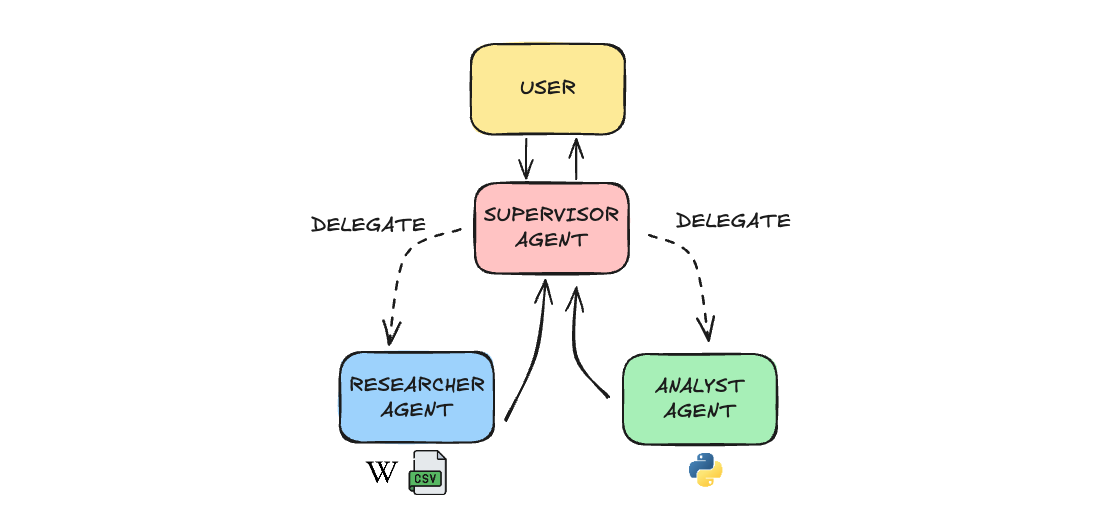

This requires a couple of updates to your current implementation:
1. Modification of the prompts used in the researcher and analyst worker agents, so they are able to collaborate effectively with the supervisor.
2. The creation of a supervisor agent node.

**Re-run the two cells below to create the environment and define the tools.**

### 🔧 Modifying the worker agent prompts

Let's first modify these agent prompts to provide specific instructions on how to work with the supervisor agent.

**Complete the code to create two one-line agents: a research agent called `"researcher"` and an analyst agent called `"analyst"`. Use the prompts provided to guide these agents.**

In [51]:
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent

llm = ChatOpenAI(model="gpt-4o-mini", api_key=api_key)

# Research agent
research_agent = create_react_agent(
    llm,
    tools=[wikipedia_tool, stock_data_tool],
    prompt=(
        "You are a research agent.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with research-related tasks, including looking-up factual information and stock data. DO NOT write any code.\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name="researcher"
)

# Analyst agent
analyst_agent = create_react_agent(
    llm,
    [python_repl_tool],
    prompt=(
        "You are an agent that can run arbitrary Python code.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with tasks that require running code to produce an output.\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name="analyst"
)

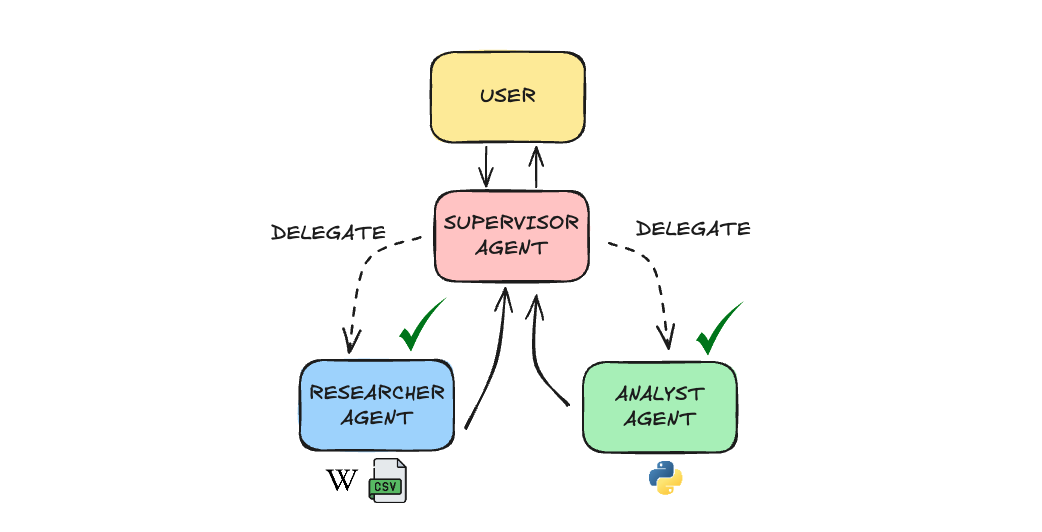


### 📋 Defining the supervisor agent

With the `"researcher"` and `"analyst"` tools defined, it's time to define the supervisor agent.

LangGraph provides the `langgraph-supervisor` library, which provides some useful abstractions to streamline the creation of supervisor multi-agent systems, and we'll be using that here.

If, instead, you'd prefer to stick to lower-level, core LangGraph code, check out [this implementation](https://langchain-ai.github.io/langgraph/tutorials/multi_agent/agent_supervisor/#3-create-supervisor-from-scratch) in the LangGraph documentation.

The `create_supervisor()` function from `langgraph-supervisor` is analogous to the `create_react_agent()` in `langgraph.prebuilt`. It provides a ready-made class that only requires the agents to manage, an LLM for the generating the text required for supervising the agents and responding to the user, and a `prompt` for dictating how to operate. Everything else, including a mechanism for building a conversation history, a function for deciding when to delegate a task, and more, are already coded into this class.

`create_supervisor()` supports many parameters to modify its default behavior, but we'll only use two here:
1. `add_handoff_back_messages`: additional messages indicating when a worker agent hands the task back to the supervisor.
2. `output_mode`: controls how messages from worker agents are added to the conversation history of the system.

In [55]:
from langgraph_supervisor import create_supervisor
from langgraph.checkpoint.memory import InMemorySaver

config = {"configurable": {"thread_id": "1", "user_id": "1"}}
checkpointer = InMemorySaver()

supervisor = create_supervisor(
    model=llm,
    agents=[research_agent, analyst_agent],
    prompt=(
        "You are a supervisor managing two agents:\n"
        "- a research agent. Assign research and data collection tasks to this agent\n"
        "- an analyst agent. Assign the creation of visualizations via code to this agent\n"
        "Assign work to one agent at a time, do not call agents in parallel.\n"
        "Do not do any work yourself."
    ),
    add_handoff_back_messages=True,
    output_mode="full_history",
).compile(checkpointer=checkpointer)

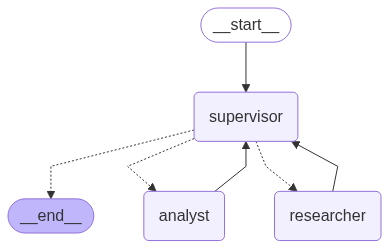

In [56]:
# Visualize your graph
supervisor

### 🧪 Testing user inputs

Time to call the supervisor agent to test out how it performs!
- Who is Apple's CEO?
- Has Tesla's share price increased over the last month?

We've used a helper function here to generate nicely-formatted outputs, but omitted it from this notebook due to its length. However, you can view it by opening the `course_helper_functions.py` file.

In [57]:
for chunk in supervisor.stream(
    {"messages": [{"role": "user", "content": "Who is Apple's CEO?"}]}, config
):
    pretty_print_messages(chunk)

Update from node supervisor:


================================ Human Message =================================

Who is Apple's CEO?
================================== Ai Message ==================================
Name: supervisor
Tool Calls:
  transfer_to_researcher (call_UY7Cz68kux7G8avXSccqxK1Q)
 Call ID: call_UY7Cz68kux7G8avXSccqxK1Q
  Args:
================================= Tool Message =================================
Name: transfer_to_researcher

Successfully transferred to researcher


Update from node researcher:


================================ Human Message =================================

Who is Apple's CEO?
================================== Ai Message ==================================
Name: supervisor
Tool Calls:
  transfer_to_researcher (call_UY7Cz68kux7G8avXSccqxK1Q)
 Call ID: call_UY7Cz68kux7G8avXSccqxK1Q
  Args:
================================= Tool Message =================================
Name: transfer_to_researcher

Successfully transferred to researcher
==

### 💡 What did we learn here?

Congratulations on creating your a supervisor multi-agent system! This is an extremely popular choice for multi-agent systems, and there isn't a limit to the number of supervisors you can have.

You can also begin to think about agents the same way that you would think about organizing a company, with different departments or business units, each unit with its own supervisor/manager, and teams within those units with their own team leads.

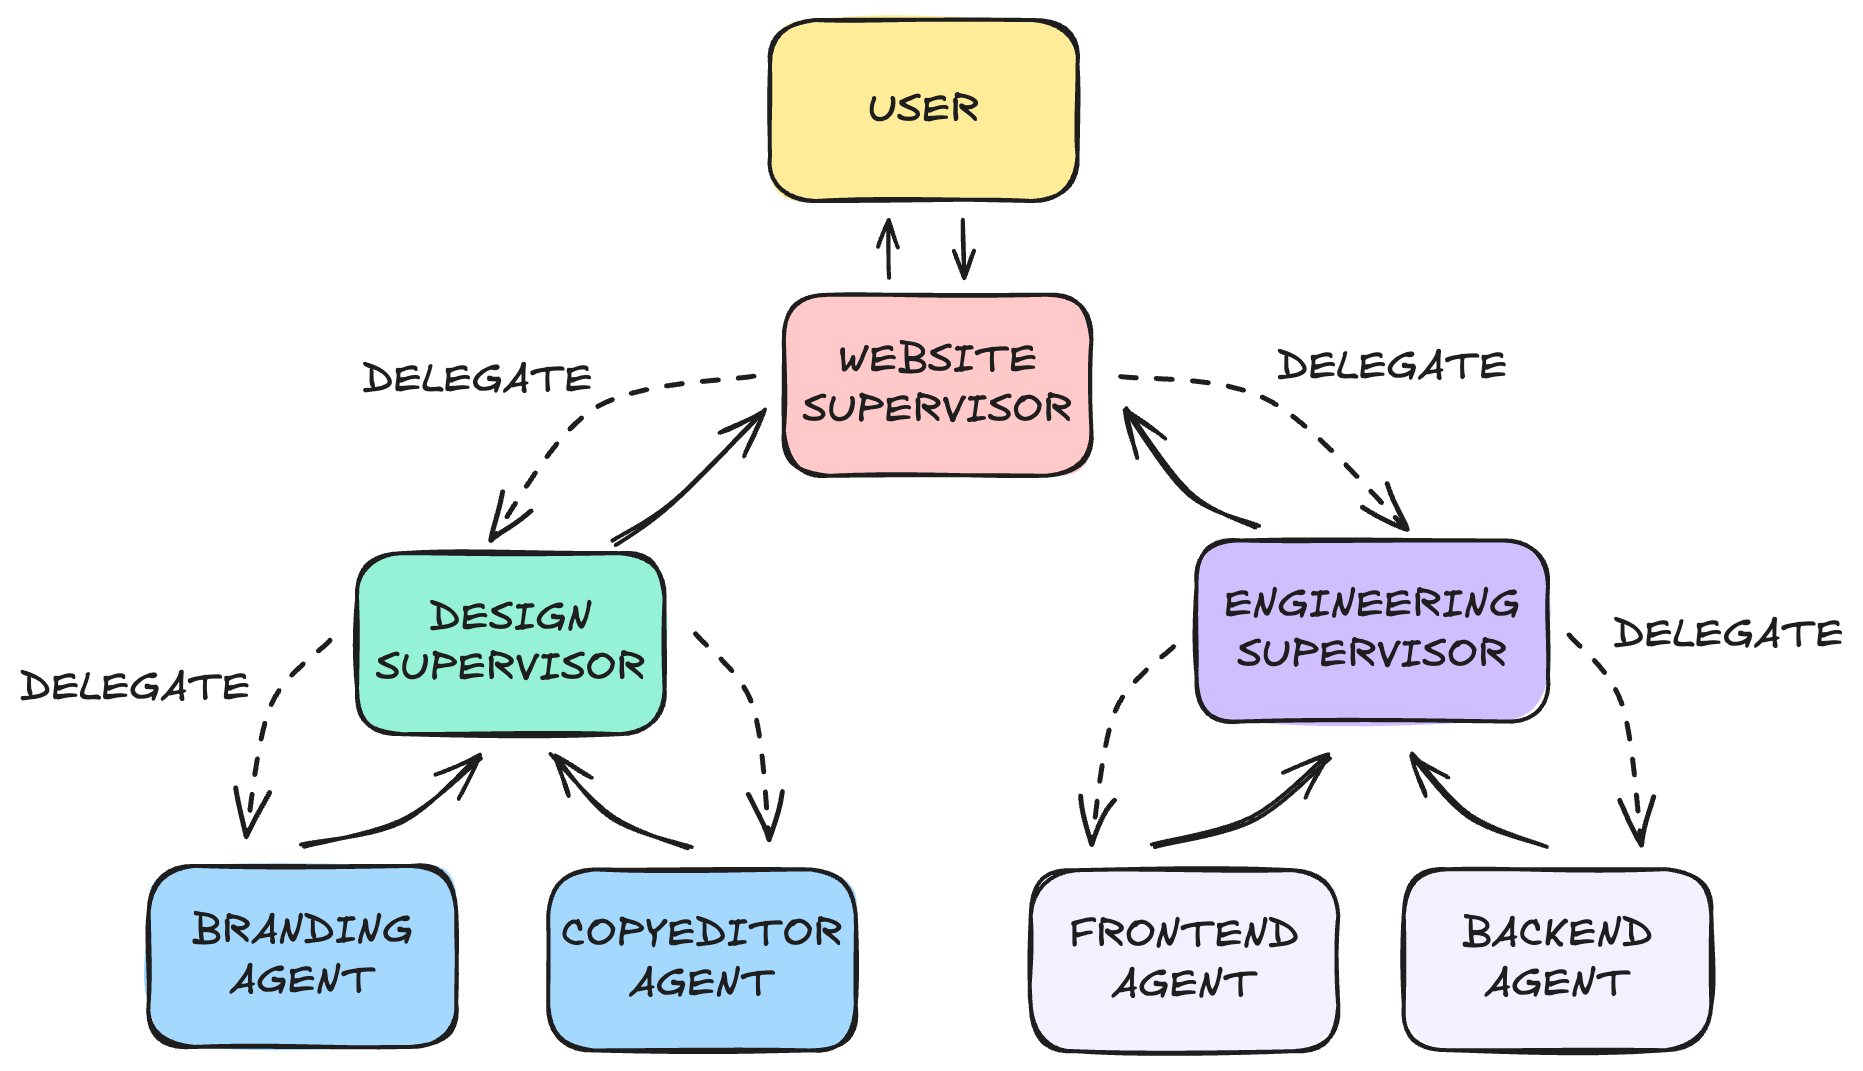

### 🧠 Some thoughts to finish on

- **There's no once-size-fits-all approach to building multi-agent systems**: the best system design is highly use case-dependent, so study the needs closely, build, and test!
- **Prompts are very important**: you may have seen while experimenting in this course, that you can connect all of the pieces together correctly, and still not get a performant system. Clear, instructive prompts are paramount for the agents to "understand" how to go about their tasks and collaborate with one another.
- **LangGraph abstractions are there if you need them**: LangGraph prides itself on providing a low-level syntax, which gives more customizability than to about any other framework. Such low-level syntax isn't for the faint-hearted, so don't be afraid to lean on some of the pre-built functionality when you're building a first-attempt project&mdash;you can always reconfigure it during the experimentation phase if the need is there.